In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [6]:
df = pd.read_csv('~/tweets/data/raw/twcs/twcs.csv')

In [7]:
data = df.copy()

In [8]:
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [7]:
# Missing info check
data.isnull().sum()

tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64

In [8]:
# Visualizing
data["customer_support_name"] = data['author_id'].str.extract('([a-zA-Z ]+)', expand=False).str.strip()

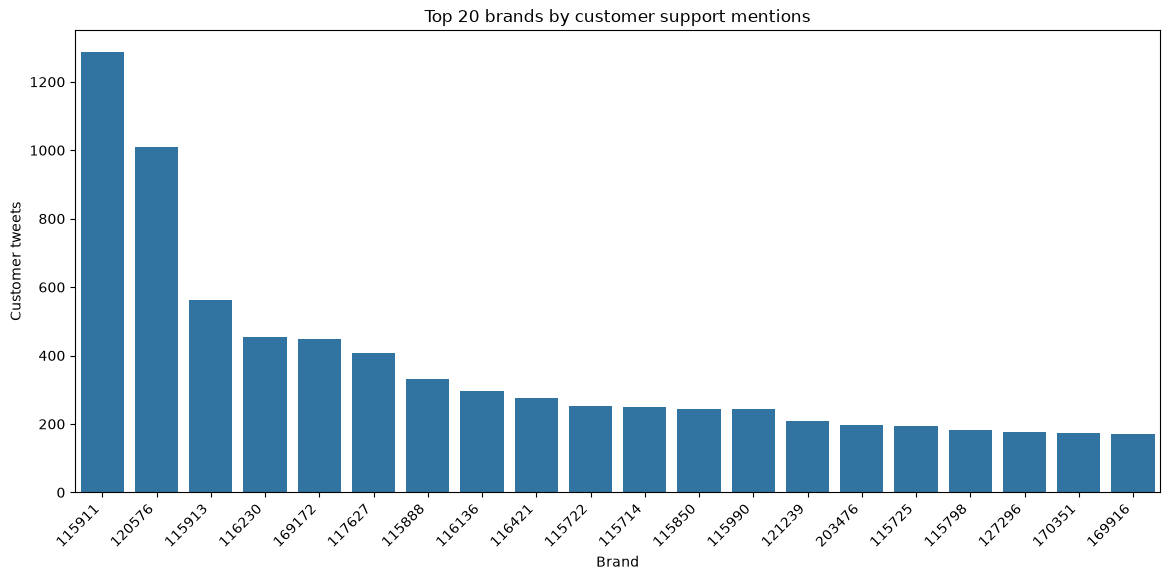

In [23]:
# customer messages per brand 
inbound = data[data["inbound"] == True]
demand = inbound["author_id"].value_counts().head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x=demand.index, y=demand.values)
plt.title('Top 20 brands by customer support mentions')
plt.xlabel('Brand')
plt.ylabel('Customer tweets')
plt.xticks(rotation=45, ha='right')
plt.show()

In [24]:
replies = data[data["inbound"] == False]["author_id"].value_counts().head(15)
print(replies)

author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
SouthwestAir        28977
VirginTrains        27817
Ask_Spectrum        25860
XboxSupport         24557
sprintcare          22381
Name: count, dtype: int64


In [26]:
brand = "AppleSupport"

brand_replies = data[(data["author_id"] == brand) & (~data["inbound"])]
thread_ids = set(brand_replies["in_response_to_tweet_id"].dropna().astype(int))

inbound = data[data["inbound"] & data["tweet_id"].isin(thread_ids)]

In [37]:
list(brand_replies["text"])[:10]

["@115854 We're here for you. Which version of the iOS are you running? Check from Settings &gt; General &gt; About.",
 "@115854 Lets take a closer look into this issue. Select the following link to join us in a DM and we'll go from there. https://t.co/GDrqU22YpT",
 "@115855 Let's go to DM for the next steps. DM us here: https://t.co/GDrqU22YpT",
 '@115855 Any steps tried since it started last night?',
 "@115855 That's great it has iOS 11.1 as we can rule out being outdated. Any steps tried since this started? Do you recall when it started?",
 "@115855 We'd like to look into this with you. Which model do you have and is iOS 11.1 installed? Any steps tried so far?",
 "@115856 Hey, let's work together to figure out what's going on. Meet us in DM and we'll continue from there. https://t.co/GDrqU22YpT",
 "@115857 We'd like to investigate further with you. Send us a DM and we can troubleshoot more from there. https://t.co/GDrqU22YpT",
 '@115857 Fill us in on what is happening, then we can h

In [43]:
def clean(text: str) -> str:
    text = str(text)
    text = re.sub(r"^RT @\w+:\s*", "", text)           # retweet prefix
    text = re.sub(r"@\w+", "[USER]", text)             # de-identify handles
    text = re.sub(r"https?://\S+|t\.co/\S+", "[LINK]", text)
    text = re.sub(r"&amp;", "&", text)
    return re.sub(r"\s+", " ", text).strip()

In [61]:
brand_threads = [clean(tweet) for tweet in inbound["text"]]

In [67]:
brand_threads[:20]

['[USER] The newest update. I️ made sure to download it yesterday.',
 '[USER] [LINK]',
 '[USER] Tried resetting my settings .. restarting my phone .. all that',
 '[USER] This is what it looks like [LINK]',
 '[USER] I️ have an iPhone 7 Plus and yes I️ do',
 '[USER] I️ need answers because it’s annoying 🙃',
 'Hey [USER] and anyone else who upgraded to ios11.1, are y’all having issues with capital “I️” in the Mail app? As it puts in “A”?',
 '[USER] This is what is happening... [LINK]',
 'Tf is wrong with my keyboard [USER]',
 '[USER] are the call centres closed for the night?',
 '[USER] [USER] hello are all the lines closed for tonight #help',
 '[USER] [USER] [USER] I️ upgraded. I️t didn’t work.',
 'Hello, internet. Can someone explain why this symbol keeps appearing on my phone and when I️ try to type the letter I️? Also [USER] [LINK]',
 '[USER] I’ve got a screenshot saying my #iPhoneX is reserved for the 3rd then an email saying it’s the 18th... what happened?',
 '[USER] I have the iPho

In [71]:
if df["inbound"].dtype != bool:
    df["inbound"] = df["inbound"].astype(str).str.lower().isin(["true", "1"])

for col in ["tweet_id", "in_response_to_tweet_id"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Loaded {len(df):,} tweets")

Loaded 2,811,774 tweets


In [72]:
df

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0
...,...,...,...,...,...,...,...
2811769,2987947,sprintcare,False,Wed Nov 22 08:43:51 +0000 2017,"@823869 Hey, we'd be happy to look into this f...",NaN,2987948.0
2811770,2987948,823869,True,Wed Nov 22 08:35:16 +0000 2017,@115714 wtf!? I’ve been having really shitty s...,2987947,NaN
2811771,2812240,121673,True,Thu Nov 23 04:13:07 +0000 2017,@143549 @sprintcare You have to go to https://...,NaN,2812239.0
2811772,2987949,AldiUK,False,Wed Nov 22 08:31:24 +0000 2017,"@823870 Sounds delicious, Sarah! 😋 https://t.c...",NaN,2987950.0


In [69]:
tweets = df.set_index("tweet_id")

In [70]:
tweets

,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
tweet_id,,,,,,
1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0
...,...,...,...,...,...,...
2987947,sprintcare,False,Wed Nov 22 08:43:51 +0000 2017,"@823869 Hey, we'd be happy to look into this f...",NaN,2987948.0
2987948,823869,True,Wed Nov 22 08:35:16 +0000 2017,@115714 wtf!? I’ve been having really shitty s...,2987947,NaN
2812240,121673,True,Thu Nov 23 04:13:07 +0000 2017,@143549 @sprintcare You have to go to https://...,NaN,2812239.0


In [73]:
children = {}
for tid, rid in zip(df["tweet_id"], df["response_tweet_id"]):
    if pd.isna(rid):
        continue
    for c in str(rid).split(","):
        c = c.strip()
        if c.isdigit():
            children.setdefault(int(tid), []).append(int(c))

In [80]:
import json
ref = [json.loads(l) for l in open("data/reference_library.jsonl")]
print(len(ref), "total,", len({r["brand_reply"] for r in ref}), "unique replies")

121078 total, 72883 unique replies


In [86]:
import json, random
held = [json.loads(l) for l in open("data/held_out.jsonl")]
random.seed(1)
for i, h in enumerate(random.sample(held, 60)):
    print(f"--- {i} ---\n{h['text'][:250]}\n")

--- 0 ---
This ios 11 is messing up my phone😤 [BRAND]

--- 1 ---
[USER] is a blessing

--- 2 ---
[USER] fuck this update i have the 7 and my phones still slow as fuck

--- 3 ---
why is my phone doing this [BRAND] [LINK]

--- 4 ---
[BRAND] I went on [LINK] and nothing showed up. I backed up from my phone when it restored and nothing showed up for about an hour or so

--- 5 ---
[BRAND] Let’s see if this works.... I

--- 6 ---
[BRAND] why does my battery drain 100x faster since the new update?

--- 7 ---
iPhone X Face ID/camera doesn’t work for me after having it for 2 days. Why you gotta do this to me [BRAND]?

--- 8 ---
[BRAND] 7+ and the newest version. Just link me IOS 10 bc iOS 11 trash and will always be trash

--- 9 ---
[BRAND] Forgot password for my itunes account. Spoke to Apple they said wait. Still waiting over a week later.

--- 10 ---
[BRAND] why did my battery life tank with the new update? Used to last all day. Now charging by 1pm

--- 11 ---
[BRAND] Seriously this update i

In [83]:
first_turns = {}
for h in held:
    first_turns.setdefault(h["thread_id"], h)  # turns were time-sorted, so first seen = earliest
held_first = list(first_turns.values())

In [10]:
apple = data[data["author_id"].eq("AppleSupport")].copy()
len(apple)

106860

In [11]:
display(apple.head())

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
396,696,AppleSupport,False,Tue Oct 31 22:27:49 +0000 2017,@115854 We're here for you. Which version of t...,697,698.0
398,699,AppleSupport,False,Tue Oct 31 22:36:27 +0000 2017,@115854 Lets take a closer look into this issu...,NaN,697.0
401,701,AppleSupport,False,Tue Oct 31 22:26:49 +0000 2017,@115855 Let's go to DM for the next steps. DM ...,NaN,702.0
403,703,AppleSupport,False,Tue Oct 31 22:09:52 +0000 2017,@115855 Any steps tried since it started last ...,702,704.0
405,705,AppleSupport,False,Tue Oct 31 21:57:00 +0000 2017,@115855 That's great it has iOS 11.1 as we can...,"706,704",707.0


In [13]:
# Finding customer tweets to AppleSupport
apple_replies = data[data["in_response_to_tweet_id"].isin(apple["tweet_id"])].copy()
print("Response Tweets to AppleSupport: ", len(apple_replies))
display(apple_replies.head(10))

Response Tweets to AppleSupport:  36660


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
397,697,115854,True,Tue Oct 31 22:31:23 +0000 2017,@AppleSupport The newest update. I️ made sure ...,699,696.0
402,702,115855,True,Tue Oct 31 22:11:31 +0000 2017,@AppleSupport Tried resetting my settings .. r...,701,703.0
404,704,115855,True,Tue Oct 31 21:59:17 +0000 2017,@AppleSupport This is what it looks like https...,703,705.0
406,707,115855,True,Tue Oct 31 21:48:51 +0000 2017,@AppleSupport I️ have an iPhone 7 Plus and yes...,705,708.0
412,713,115856,True,Tue Oct 31 22:35:17 +0000 2017,@AppleSupport Just sent you all my DM,NaN,712.0
415,717,115857,True,Tue Oct 31 22:13:08 +0000 2017,@AppleSupport This is what is happening... htt...,716,718.0
419,721,115859,True,Tue Oct 31 22:18:14 +0000 2017,@AppleSupport are the call centres closed for ...,720,722.0
425,728,115862,True,Tue Oct 31 20:57:26 +0000 2017,@AppleSupport @115861 We’re going to need you ...,727,729.0
431,735,115864,True,Tue Oct 31 22:23:35 +0000 2017,@AppleSupport I have the iPhone 6s Plus and ju...,737,734.0
435,739,115865,True,Tue Oct 31 22:35:32 +0000 2017,@AppleSupport iOS 11.0.3,741,738.0


In [14]:
apple_inbound = df[
    df["inbound"].eq(True) &
    (
        df["in_response_to_tweet_id"].isin(apple["tweet_id"]) |
        df["response_tweet_id"].isin(apple["tweet_id"])
    )
].copy()

print("Customer tweets linked to AppleSupport:", len(apple_inbound))
display(apple_inbound.head(10))

Customer tweets linked to AppleSupport: 36658


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
397,697,115854,True,Tue Oct 31 22:31:23 +0000 2017,@AppleSupport The newest update. I️ made sure ...,699,696.0
402,702,115855,True,Tue Oct 31 22:11:31 +0000 2017,@AppleSupport Tried resetting my settings .. r...,701,703.0
404,704,115855,True,Tue Oct 31 21:59:17 +0000 2017,@AppleSupport This is what it looks like https...,703,705.0
406,707,115855,True,Tue Oct 31 21:48:51 +0000 2017,@AppleSupport I️ have an iPhone 7 Plus and yes...,705,708.0
412,713,115856,True,Tue Oct 31 22:35:17 +0000 2017,@AppleSupport Just sent you all my DM,NaN,712.0
415,717,115857,True,Tue Oct 31 22:13:08 +0000 2017,@AppleSupport This is what is happening... htt...,716,718.0
419,721,115859,True,Tue Oct 31 22:18:14 +0000 2017,@AppleSupport are the call centres closed for ...,720,722.0
425,728,115862,True,Tue Oct 31 20:57:26 +0000 2017,@AppleSupport @115861 We’re going to need you ...,727,729.0
431,735,115864,True,Tue Oct 31 22:23:35 +0000 2017,@AppleSupport I have the iPhone 6s Plus and ju...,737,734.0
435,739,115865,True,Tue Oct 31 22:35:32 +0000 2017,@AppleSupport iOS 11.0.3,741,738.0


In [15]:
apple = df[df["author_id"].eq("AppleSupport")].copy()

display(
    apple[
        [
            "tweet_id",
            "author_id",
            "inbound",
            "text",
            "response_tweet_id",
            "in_response_to_tweet_id",
        ]
    ].head(20)
)

,tweet_id,author_id,inbound,text,response_tweet_id,in_response_to_tweet_id
396,696,AppleSupport,False,@115854 We're here for you. Which version of t...,697,698.0
398,699,AppleSupport,False,@115854 Lets take a closer look into this issu...,NaN,697.0
401,701,AppleSupport,False,@115855 Let's go to DM for the next steps. DM ...,NaN,702.0
403,703,AppleSupport,False,@115855 Any steps tried since it started last ...,702,704.0
405,705,AppleSupport,False,@115855 That's great it has iOS 11.1 as we can...,"706,704",707.0
407,708,AppleSupport,False,@115855 We'd like to look into this with you. ...,707,709.0
411,712,AppleSupport,False,"@115856 Hey, let's work together to figure out...",713,714.0
414,716,AppleSupport,False,@115857 We'd like to investigate further with ...,NaN,717.0
416,718,AppleSupport,False,"@115857 Fill us in on what is happening, then ...",717,719.0
418,720,AppleSupport,False,@115859 We've received your DM and will contin...,NaN,721.0


In [18]:
tweet_id = 722

tweet = data[data["tweet_id"] == tweet_id]
display(tweet)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
420,722,AppleSupport,False,Tue Oct 31 22:17:30 +0000 2017,@115859 What's going on? We're hapy to help if...,721,723.0


In [19]:
parent_tweet = tweet.iloc[0]["in_response_to_tweet_id"]
print("Parent tweet id:", parent_tweet)

Parent tweet id: 723.0


In [25]:
parent = data[data["tweet_id"] == parent_tweet]
display(parent)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
421,723,115859,True,Tue Oct 31 22:11:16 +0000 2017,@115858 @AppleSupport hello are all the lines ...,722,NaN


In [26]:
children = data[data["in_response_to_tweet_id"] == tweet_id]
display(children)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
419,721,115859,True,Tue Oct 31 22:18:14 +0000 2017,@AppleSupport are the call centres closed for ...,720,722.0


In [29]:
print("apple tweets with parents: ", apple["in_response_to_tweet_id"].notna().sum())
print("apple tweets with response: ", apple["response_tweet_id"].notna().sum())
print("standalone apple tweets: ",(apple["in_response_to_tweet_id"].isna() & apple["response_tweet_id"].isna()).sum())

apple tweets with parents:  106719
apple tweets with response:  31564
standalone apple tweets:  0


In [30]:
apple["inbound"].value_counts(dropna=False)

inbound
False    106860
Name: count, dtype: int64

In [31]:
print("Total tweets:", len(data))
print("Unique tweet IDs:", data["tweet_id"].nunique())
print("Duplicate tweet IDs:", data["tweet_id"].duplicated().sum())
print("Missing tweet IDs:", data["tweet_id"].isna().sum())

Total tweets: 2811774
Unique tweet IDs: 2811774
Duplicate tweet IDs: 0
Missing tweet IDs: 0


In [32]:
tweet_lookup = data.set_index("tweet_id").to_dict("index")
tweet_lookup[722]

{'author_id': 'AppleSupport',
 'inbound': False,
 'created_at': 'Tue Oct 31 22:17:30 +0000 2017',
 'text': "@115859 What's going on? We're hapy to help if we can. https://t.co/GDrqU22YpT",
 'response_tweet_id': '721',
 'in_response_to_tweet_id': 723.0}

In [ ]:
def get_parent(tweet_id):
    r = tweet_lookup.get(tweet_id)
    